In [1]:
# Install necessary Qiskit packages
!pip install qiskit-ibm-runtime qiskit-aer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00


In [6]:
import os
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Retrieve the API key from Colab Secrets
api_key = userdata.get('ibm')

# Save and load your IBM Quantum account
# 'ibm_quantum' is for the open/standard plan; 'ibm_cloud' is for enterprise
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=api_key, overwrite=True)
service = QiskitRuntimeService()

# Verify connection by listing available backends
print("Available Backends:")
for backend in service.backends():
    print(f"- {backend.name}")

qiskit_runtime_service.__init__:WARNING:2026-04-03 00:28:16,080: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: dataset_hom. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 00:28:16,080: Loading instance: dataset_hom, plan: open


Available Backends:
- ibm_fez
- ibm_kingston
- ibm_marrakesh


Designing a robust hardware selection algorithm is the critical bridge between theoretical quantum mechanics and experimental success. Building on our previous discussions about isolating the perfect 4-qubit chain for your ML-QEM workflow, the algorithm needs to autonomously ingest raw calibration data and output the absolute best physical routing for the beam splitter.

Here is the formalized, step-by-step algorithm design that processes calibration data into an optimal hardware decision, tailored specifically for structured Gray code circuits.

### **Phase 1: Calibration Data Ingestion**
The algorithm begins by pulling the daily calibration metrics for all available backends (e.g., `ibm_fez`, `ibm_kingston`).
* **Target Variables:** * Relaxation time ($T_1$)
    * Dephasing time ($T_2$)
    * Single-qubit readout assignment error
    * Two-qubit gate infidelity (specifically the native **CZ** or **CX** errors).
* **Operational Filter:** Instantly drop any qubits flagged as `Operational = False`.

---

### **Phase 2: Global Coherence Thresholding**
Before looking at connectivity, the algorithm purges qubits that cannot support the 178-layer Trotterized depth.
* **Calculate Median:** Determine the median $T_1$ and $T_2$ for the entire backend.
* **Pruning:** Eliminate any qubit whose $T_1$ or $T_2$ falls below a defined minimum threshold (e.g., the bottom 25th percentile). This prevents a single "dead" qubit from destroying the Hong-Ou-Mandel interference signal before measurement.

---

### **Phase 3: Topological Subgraph Mapping (The SWAP-Avoider)**
This is the most computationally important step. Your logical circuit requires a specific interaction pattern: Qubit 0 ↔ 1, Qubit 2 ↔ 3, and Qubit 1 ↔ 3.
* **Graph Construction:** Convert the physical backend's `coupling_map` into a directed graph.
* **Subgraph Search:** Scan the high-coherence pool (from Phase 2) to find all physical subgraphs that match your logical "Chain" topology (nodes arranged as $A - B - C - D$).
* **Validation:** Ensure that connecting these four qubits requires **zero SWAP gates**.

---

### **Phase 4: Cluster Scoring & Optimization**
For every valid 4-qubit cluster found in Phase 3, the algorithm calculates a "Composite Fidelity Score" to find the true winner.

**The Cost Function:**
The algorithm minimizes a cost function $C$ that penalizes high gate errors and rewards long coherence times. A standard representation looks like this:

$$C_{cluster} = \sum_{i \in edges} (\text{GateError}_i) + \sum_{j \in nodes} (\text{ReadoutError}_j) + \lambda \sum_{j \in nodes} \left( \frac{\text{GateTime}}{T_{1, j}} + \frac{\text{GateTime}}{T_{2, j}} \right)$$

* *Edges:* The specific CZ/CX connections used in the cluster.
* *Nodes:* The individual qubits.
* *$\lambda$:* A weighting factor to balance gate errors against natural decoherence.

---

### **Phase 5: Automated Selection & Feature Export**
* **Ranking:** The clusters are ranked from lowest cost to highest.
* **Selection:** The algorithm selects the cluster with the lowest $C_{cluster}$.
* **Feature Export:** The algorithm exports the specific $T_1, T_2$, and CZ errors of this winning cluster as the $X$ features for your Random Forest training matrix.

This ensures your machine learning model is trained exactly on the "noise DNA" of the hardware that will execute the final simulation.


In [16]:
# --- BLOCK 1: AUTOMATED HARDWARE SELECTION ---
import numpy as np
import networkx as nx
from qiskit_ibm_runtime import QiskitRuntimeService

class AutomatedQEMSelector:
    def __init__(self, token=None, channel="ibm_quantum_platform", lambda_weight=100, coherence_percentile=25):
        print("Authenticating with IBM Quantum...")
        self.service = QiskitRuntimeService(channel=channel, token=token)
        self.lambda_weight = lambda_weight
        self.coherence_percentile = coherence_percentile

    def _extract_qubit_properties(self, props, qubit_idx):
        try:
            t1 = next((p.value for p in props.qubits[qubit_idx] if p.name == 'T1'), 0) * 1e6
            t2 = next((p.value for p in props.qubits[qubit_idx] if p.name == 'T2'), 0) * 1e6
            readout = next((p.value for p in props.qubits[qubit_idx] if p.name == 'readout_error'), 1.0)
            return t1, t2, readout
        except StopIteration:
            return 0, 0, 1.0

    def get_backend_graph(self, backend):
        G = nx.Graph()
        props = backend.properties()
        if not props: return None

        num_qubits = len(props.qubits)
        all_t1, all_t2 = [], []

        for i in range(num_qubits):
            t1, t2, _ = self._extract_qubit_properties(props, i)
            if t1 > 0 and t2 > 0:
                all_t1.append(t1), all_t2.append(t2)

        if not all_t1: return None
        t1_thresh = np.percentile(all_t1, self.coherence_percentile)
        t2_thresh = np.percentile(all_t2, self.coherence_percentile)

        for i in range(num_qubits):
            t1, t2, readout = self._extract_qubit_properties(props, i)
            if t1 >= t1_thresh and t2 >= t2_thresh:
                G.add_node(i, T1=t1, T2=t2, readout=readout)

        for gate in props.gates:
            if gate.gate in ['cz', 'cx']:
                q1, q2 = gate.qubits
                if q1 in G.nodes and q2 in G.nodes:
                    error = props.gate_error(gate.gate, [q1, q2])
                    if G.has_edge(q1, q2):
                        G[q1][q2]['weight'] = min(G[q1][q2]['weight'], error)
                    else:
                        G.add_edge(q1, q2, weight=error)
        return G

    def calculate_cost(self, G, path):
        gate_err = sum(G[path[i]][path[i+1]]['weight'] for i in range(3))
        readout_err = sum(G.nodes[q]['readout'] for q in path)
        decoherence = sum((1 / G.nodes[q]['T1']) + (1 / G.nodes[q]['T2']) for q in path)
        return gate_err + readout_err + (self.lambda_weight * decoherence)

    def find_best_overall_mapping(self):
        all_clusters = []
        backends = self.service.backends(simulator=False, operational=True, min_num_qubits=4)

        for backend in backends:
            try:
                G = self.get_backend_graph(backend)
                if G is None: continue

                all_nodes = list(G.nodes())
                for source in all_nodes:
                    valid_targets = [n for n in all_nodes if n != source]
                    for path in nx.all_simple_paths(G, source=source, target=valid_targets, cutoff=3):
                        if len(path) == 4:
                            if path[0] > path[-1]: continue # Ignore reverse paths

                            cost = self.calculate_cost(G, path)
                            avg_t1 = np.mean([G.nodes[q]['T1'] for q in path])
                            avg_t2 = np.mean([G.nodes[q]['T2'] for q in path])
                            avg_readout = np.mean([G.nodes[q]['readout'] for q in path])
                            avg_gate_err = np.mean([G[path[i]][path[i+1]]['weight'] for i in range(3)])

                            all_clusters.append({
                                'backend': backend.name,
                                'physical_qubits': path,
                                'logical_mapping': f"0->{path[0]}, 1->{path[1]}, 3->{path[2]}, 2->{path[3]}",
                                'cost': cost,
                                'features': {'avg_T1': avg_t1, 'avg_T2': avg_t2, 'avg_readout_err': avg_readout, 'avg_cz_error': avg_gate_err}
                            })
            except Exception:
                pass

        if not all_clusters:
            raise RuntimeError("No valid clusters found.")

        final_ranking = sorted(all_clusters, key=lambda x: x['cost'])
        return final_ranking[0]

# --- EXECUTION ---
print("Authenticating and Initiating Hardware Search...")
optimal_hardware = None
current_percentile = 25

while current_percentile >= 0 and optimal_hardware is None:
    try:
        print(f"Scanning chips (Coherence Threshold: Top {100-current_percentile}%)...")
        selector = AutomatedQEMSelector(coherence_percentile=current_percentile)
        optimal_hardware = selector.find_best_overall_mapping() # Saved to memory!
    except RuntimeError:
        print(f"  [!] Too fragmented. Relaxing threshold to {current_percentile - 5}%.")
        current_percentile -= 5

if optimal_hardware:
    print("\n" + "="*50)
    print(f"🏆 LOCKED IN: {optimal_hardware['backend']} on Qubits {optimal_hardware['physical_qubits']}")
    print("="*50)
else:
    print("CRITICAL FAILURE: Cannot find a valid cluster on any backend.")

Authenticating and Initiating Hardware Search...
Scanning chips (Coherence Threshold: Top 75%)...
Authenticating with IBM Quantum...


qiskit_runtime_service.__init__:WARNING:2026-04-03 00:58:18,564: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: dataset_hom. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 00:58:18,565: Loading instance: dataset_hom, plan: open



🏆 LOCKED IN: ibm_marrakesh on Qubits [4, 5, 6, 7]


# Dataset Generation

In [18]:
# --- BLOCK 2: QUEUE-AWARE DATASET GENERATION (UPDATED) ---
import numpy as np
import pandas as pd
import time
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

def generate_hardware_aware_dataset(backend_name, opt_qubits, hw_features, num_samples=15):
    print(f"\n--- Building Dataset on {backend_name} using qubits {opt_qubits} ---")
    service = QiskitRuntimeService(channel="ibm_quantum")
    backend = service.backend(backend_name)
    noiseless_sim = AerSimulator()

    thetas = np.linspace(0, np.pi/2, num_samples)
    trotter_steps = [1, 2, 3]

    qpu_circuits = []
    ideal_circuits = []
    metadata = []

    for step in trotter_steps:
        for theta in thetas:
            qr = QuantumRegister(4, 'q')
            cr = ClassicalRegister(4, 'c')
            qc = QuantumCircuit(qr, cr)

            qc.x([qr[1], qr[3]]) # Initial state |0101>

            for _ in range(step):
                qc.ry(theta / step, [qr[1], qr[3]])
                # Gray Code Bridges
                qc.cx(qr[1], qr[0])
                qc.cx(qr[3], qr[2])
                qc.cx(qr[1], qr[3])

            qc.measure(qr, cr)

            # STRICT HARDWARE LOCKING
            t_qc = transpile(qc, backend=backend, initial_layout=opt_qubits, optimization_level=0)
            qpu_circuits.append(t_qc)
            ideal_circuits.append(transpile(qc, backend=noiseless_sim))
            metadata.append({"theta": theta, "trotter_steps": step})

    print("Simulating ideal targets...")
    ideal_counts = noiseless_sim.run(ideal_circuits, shots=10000).result().get_counts()

    sampler = SamplerV2(mode=backend)
    print("Submitting circuits to IBM Quantum...")
    job = sampler.run([(c,) for c in qpu_circuits])

    print(f"Job ID: {job.job_id()}")

    # --- ROBUST STATUS CHECK FIX ---
    while str(job.status()).upper() not in ['DONE', 'CANCELLED', 'ERROR']:
        print(f"Status: {str(job.status()).upper()} (Waiting 30s...)")
        time.sleep(30)

    if str(job.status()).upper() != 'DONE':
        raise RuntimeError(f"Job failed: {job.status()}")

    print("Job completed! Aggregating data...")
    qpu_results = job.result()

    final_data = []
    for i in range(len(qpu_circuits)):
        pub_counts = qpu_results[i].data.c.get_counts()
        total_shots = sum(pub_counts.values())

        noisy_val = (pub_counts.get('1100', 0) + pub_counts.get('0011', 0)) / total_shots
        ideal_val = (ideal_counts[i].get('1100', 0) + ideal_counts[i].get('0011', 0)) / 10000

        final_data.append({
            **hw_features,
            **metadata[i],
            "noisy_expectation": noisy_val,
            "ideal_target": ideal_val
        })

    df = pd.DataFrame(final_data)
    filename = f"hom_ml_data_{backend_name}.csv"
    df.to_csv(filename, index=False)
    print(f"✅ Success! Saved '{filename}'")
    return df

# --- EXECUTION ---
if 'optimal_hardware' in locals() and optimal_hardware is not None:
    best_backend = optimal_hardware['backend']
    best_qubits = optimal_hardware['physical_qubits']
    hw_features = optimal_hardware['features']

    dataset_df = generate_hardware_aware_dataset(
        backend_name=best_backend,
        opt_qubits=best_qubits,
        hw_features=hw_features,
        num_samples=15
    )
else:
    print("Error: 'optimal_hardware' is not defined. Please run Block 1 first!")


--- Building Dataset on ibm_marrakesh using qubits [4, 5, 6, 7] ---


qiskit_runtime_service.__init__:WARNING:2026-04-03 00:59:14,350: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: dataset_hom. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 00:59:14,350: Using instance: dataset_hom, plan: open


Simulating ideal targets...
Submitting circuits to IBM Quantum...
Job ID: d77h1q8eecps73d62c50


AttributeError: 'str' object has no attribute 'name'

In [21]:
# RESCUE BLOCK
import numpy as np
import pandas as pd
import time
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# --- RESCUE BLOCK: Retrieve existing job ---
print("Reconnecting to IBM Quantum to rescue job...")
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Re-define necessary variables from the original dataset generation logic
if 'optimal_hardware' in locals() and optimal_hardware is not None:
    best_backend = optimal_hardware['backend']
    best_qubits = optimal_hardware['physical_qubits']
    # hw_features is already in global scope from optimal_hardware
else:
    raise RuntimeError("Error: 'optimal_hardware' is not defined. Cannot rescue job without hardware context.")

backend = service.backend(best_backend)
noiseless_sim = AerSimulator()

num_samples = 15 # Assuming the same num_samples as original call
thetas = np.linspace(0, np.pi/2, num_samples)
trotter_steps = [1, 2, 3]

qpu_circuits = []
ideal_circuits = []
metadata = []

for step in trotter_steps:
    for theta in thetas:
        qr = QuantumRegister(4, 'q')
        cr = ClassicalRegister(4, 'c')
        qc = QuantumCircuit(qr, cr)

        qc.x([qr[1], qr[3]]) # Initial state |0101>

        for _ in range(step):
            qc.ry(theta / step, [qr[1], qr[3]])
            # Gray Code Bridges
            qc.cx(qr[1], qr[0])
            qc.cx(qr[3], qr[2])
            qc.cx(qr[1], qr[3])

        qc.measure(qr, cr)

        # STRICT HARDWARE LOCKING
        t_qc = transpile(qc, backend=backend, initial_layout=best_qubits, optimization_level=0)
        qpu_circuits.append(t_qc)
        ideal_circuits.append(transpile(qc, backend=noiseless_sim))
        metadata.append({"theta": theta, "trotter_steps": step})

print("Simulating ideal targets for rescue...")
ideal_counts = noiseless_sim.run(ideal_circuits, shots=10000).result().get_counts()

# Fetch your specific job
job = service.job("d77h1q8eecps73d62c50")

# Fixed Queue Monitor
while str(job.status()).upper() not in ['DONE', 'CANCELLED', 'ERROR']:
    print(f"Status: {str(job.status()).upper()} (Waiting 30s...)")
    time.sleep(30)

if str(job.status()).upper() != 'DONE':
    print(f"Job failed with status: {job.status()}")
else:
    print("Job completed! Aggregating rescued data...")
    qpu_results = job.result()

    final_data = []
    # Using the lengths and metadata still in your active memory
    for i in range(len(qpu_circuits)):
        pub_counts = qpu_results[i].data.c.get_counts()
        total_shots = sum(pub_counts.values())

        noisy_val = (pub_counts.get('1100', 0) + pub_counts.get('0011', 0)) / total_shots
        ideal_val = (ideal_counts[i].get('1100', 0) + ideal_counts[i].get('0011', 0)) / 10000

        final_data.append({
            **hw_features,
            **metadata[i],
            "noisy_expectation": noisy_val,
            "ideal_target": ideal_val
        })

    df = pd.DataFrame(final_data)
    filename = f"hom_ml_data_ibm_marrakesh.csv"
    df.to_csv(filename, index=False)
    print(f"✅ Rescue Success! Saved '{filename}'")


Reconnecting to IBM Quantum to rescue job...


qiskit_runtime_service.__init__:WARNING:2026-04-03 01:04:10,387: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: dataset_hom. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 01:04:10,388: Using instance: dataset_hom, plan: open


Simulating ideal targets for rescue...
Job completed! Aggregating rescued data...
✅ Rescue Success! Saved 'hom_ml_data_ibm_marrakesh.csv'


# Machine Learning Models Performace

Dataset 'hom_ml_data_ibm_marrakesh.csv' loaded successfully. Shape: (45, 8)

🧠 ML-QEM MITIGATION RESULTS 🧠
Baseline Hardware Error (Unmitigated MAE): 0.03326

--- Single Decision Tree ---
Mitigated MAE: 0.02298
Improvement  : 30.90%
--- Random Forest (Bagging) ---
Mitigated MAE: 0.00726
Improvement  : 78.17%
--- Gradient Boosting (Boosting) ---
Mitigated MAE: 0.01517
Improvement  : 54.40%

Plot saved as 'ml_qem_benchmark_results.png'.


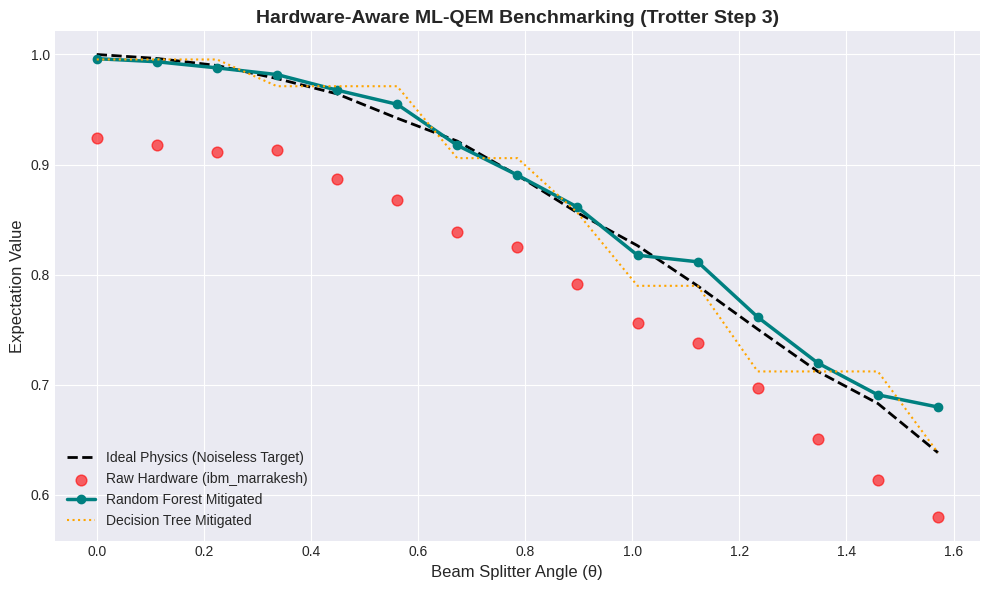

In [22]:
# --- BLOCK 4: ML BENCHMARKING & VISUALIZATION ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# 1. Load the Dataset
filename = "hom_ml_data_ibm_marrakesh.csv"
try:
    df = pd.read_csv(filename)
    print(f"Dataset '{filename}' loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: '{filename}' not found. Ensure Block 2 or the Rescue Block finished saving.")
    raise

# 2. Define Features and Targets
features = [
    'noisy_expectation', 'theta', 'trotter_steps',
    'avg_T1', 'avg_T2', 'avg_readout_err', 'avg_cz_error'
]
X = df[features]
y = df['ideal_target']

# 3. Train/Test Split (80% training, 20% unseen testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. Initialize the Three Models
models = {
    "Single Decision Tree": DecisionTreeRegressor(max_depth=4, random_state=42),
    "Random Forest (Bagging)": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "Gradient Boosting (Boosting)": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# Calculate baseline unmitigated error
baseline_mae = mean_absolute_error(y_test, X_test['noisy_expectation'])

print("\n" + "="*50)
print("🧠 ML-QEM MITIGATION RESULTS 🧠")
print("="*50)
print(f"Baseline Hardware Error (Unmitigated MAE): {baseline_mae:.5f}\n")

trained_models = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict and score
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    improvement = ((baseline_mae - mae) / baseline_mae) * 100

    print(f"--- {name} ---")
    print(f"Mitigated MAE: {mae:.5f}")
    print(f"Improvement  : {improvement:.2f}%")

print("="*50)

# ==========================================
# 5. Thesis Visualization (Plotting Step 3)
# ==========================================
# We isolate Trotter Step 3 for the plot because it shows the deepest circuit noise
plot_data = df[df['trotter_steps'] == 3].sort_values(by='theta')

# Extract plotting axes
theta_vals = plot_data['theta']
ideal_vals = plot_data['ideal_target']
noisy_vals = plot_data['noisy_expectation']

# Generate predictions for the continuous curve
X_plot = plot_data[features]
rf_preds = trained_models["Random Forest (Bagging)"].predict(X_plot)
dt_preds = trained_models["Single Decision Tree"].predict(X_plot)

# Create the plot
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-darkgrid')

# Plot the physics curves
plt.plot(theta_vals, ideal_vals, 'k--', linewidth=2, label='Ideal Physics (Noiseless Target)')
plt.scatter(theta_vals, noisy_vals, color='red', alpha=0.6, s=60, label='Raw Hardware (ibm_marrakesh)')

# Plot the ML Mitigations
plt.plot(theta_vals, rf_preds, color='teal', linewidth=2.5, marker='o', label='Random Forest Mitigated')
plt.plot(theta_vals, dt_preds, color='orange', linewidth=1.5, linestyle=':', label='Decision Tree Mitigated')

# Formatting
plt.title('Hardware-Aware ML-QEM Benchmarking (Trotter Step 3)', fontsize=14, fontweight='bold')
plt.xlabel('Beam Splitter Angle (θ)', fontsize=12)
plt.ylabel('Expectation Value', fontsize=12)
plt.legend(fontsize=10, loc='lower left')
plt.tight_layout()

# Save and show
plt.savefig('ml_qem_benchmark_results.png', dpi=300)
print("\nPlot saved as 'ml_qem_benchmark_results.png'.")
plt.show()

# Comparison with existing methods


Initializing Native ZNE Comparison...


qiskit_runtime_service.__init__:WARNING:2026-04-03 01:19:45,197: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: dataset_hom. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 01:19:45,198: Using instance: dataset_hom, plan: open


Observable mapped to physical register: 156 qubits.
Submitting 9 test circuits for ZNE mitigation...
ZNE Job ID: d77hbcgeecps73d62m00
Status: QUEUED (Waiting 30s...)
Status: RUNNING (Waiting 30s...)
ZNE execution complete! Calculating errors...

🏆 FINAL ML-QEM vs ZNE PERFORMANCE LEADERBOARD 🏆
1. Unmitigated Hardware MAE : 0.03326
------------------------------------------------------------
2. Classical ZNE MAE        : 0.06183 (Imp: -85.9%)
3. Single Decision Tree MAE : 0.02298 (Imp: 30.9%)
4. Gradient Boosting MAE    : 0.01517 (Imp: 54.4%)
5. Random Forest MAE        : 0.00726 (Imp: 78.2%)


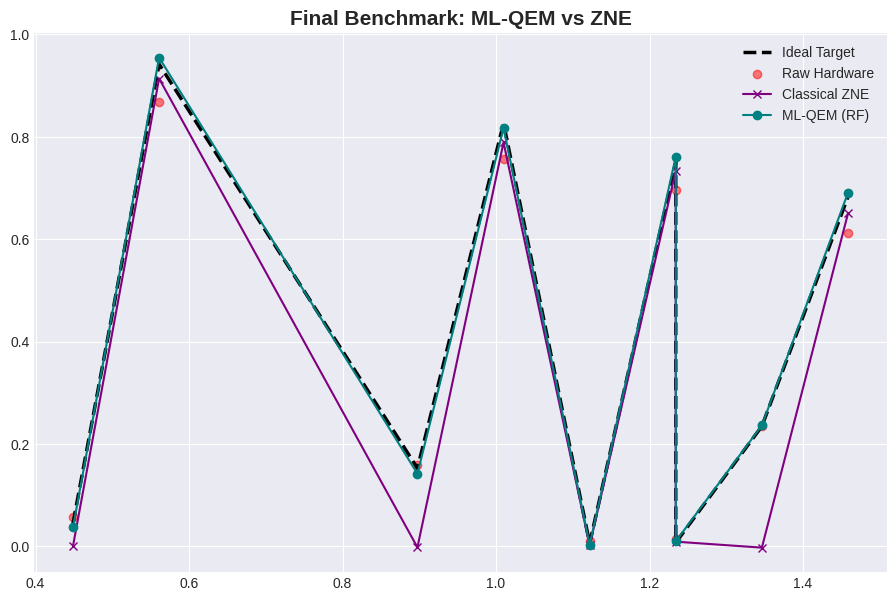

In [32]:
# --- BLOCK 5: ZNE EXECUTION & FINAL COMPARISON (FIXED FOR 156-QUBIT DEVICE) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from qiskit import QuantumCircuit, transpile, QuantumRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, EstimatorOptions

print("Initializing Native ZNE Comparison...")

# 1. Connect and Define Mapping
service = QiskitRuntimeService(channel="ibm_quantum_platform")
backend_name = df['backend'].iloc[0] if 'backend' in df.columns else "ibm_marrakesh"
backend = service.backend(backend_name)
opt_qubits = [4, 5, 6, 7]

# 2. Extract Test Data from memory
test_thetas = X_test['theta'].values
test_steps = X_test['trotter_steps'].values
y_true = y_test.values
baseline_noisy = X_test['noisy_expectation'].values

# 3. Define and EXPAND the Observable
# We start with the 4-qubit logical observable
base_obs = SparsePauliOp.from_list([
    ("IIII", 0.125), ("ZZII", 0.125), ("IIZZ", 0.125), ("ZZZZ", 0.125),
    ("ZIZI", -0.125), ("IZIZ", -0.125), ("ZIIZ", -0.125), ("IZZI", -0.125)
])

# CRITICAL FIX: Map the 4-qubit op to the 156-qubit physical device
# This places our Pauli strings on qubits 4, 5, 6, 7 and "I" everywhere else.
ob_string = base_obs.apply_layout(layout=opt_qubits, num_qubits=backend.num_qubits)
print(f"Observable mapped to physical register: {ob_string.num_qubits} qubits.")

# 4. Build the Test Set Circuits
zne_circuits = []
for step, theta in zip(test_steps, test_thetas):
    qr = QuantumRegister(4, 'q')
    qc = QuantumCircuit(qr)
    qc.x([qr[1], qr[3]])
    for _ in range(int(step)):
        qc.ry(theta / step, [qr[1], qr[3]])
        qc.cx(qr[1], qr[0])
        qc.cx(qr[3], qr[2])
        qc.cx(qr[1], qr[3])

    # Transpiling for the full 156-qubit backend
    t_qc = transpile(qc, backend=backend, initial_layout=opt_qubits, optimization_level=0)
    zne_circuits.append(t_qc)

# 5. Setup ZNE Options
options = EstimatorOptions()
options.resilience_level = 2
options.resilience.zne_mitigation = True
try:
    options.resilience.zne.extrapolator = "linear"
except AttributeError:
    options.resilience.zne_extrapolator = "linear"

# 6. Execute
print(f"Submitting {len(zne_circuits)} test circuits for ZNE mitigation...")
estimator = EstimatorV2(mode=backend, options=options)
pubs = [(circ, ob_string) for circ in zne_circuits]
job = estimator.run(pubs=pubs)

print(f"ZNE Job ID: {job.job_id()}")
while str(job.status()).upper() not in ['DONE', 'CANCELLED', 'ERROR']:
    print(f"Status: {str(job.status()).upper()} (Waiting 30s...)")
    time.sleep(30)

# 7. Aggregate and Calculate Errors
print("ZNE execution complete! Calculating errors...")
zne_results = job.result()
zne_preds = [result.data.evs for result in zne_results]

mae_baseline = mean_absolute_error(y_true, baseline_noisy)
mae_zne = mean_absolute_error(y_true, zne_preds)
mae_dt = mean_absolute_error(y_true, trained_models["Single Decision Tree"].predict(X_test))
mae_rf = mean_absolute_error(y_true, trained_models["Random Forest (Bagging)"].predict(X_test))
mae_gb = mean_absolute_error(y_true, trained_models["Gradient Boosting (Boosting)"].predict(X_test))

# 8. The Leaderboard
print("\n" + "="*60)
print("🏆 FINAL ML-QEM vs ZNE PERFORMANCE LEADERBOARD 🏆")
print("="*60)
print(f"1. Unmitigated Hardware MAE : {mae_baseline:.5f}")
print("-" * 60)
print(f"2. Classical ZNE MAE        : {mae_zne:.5f} (Imp: {((mae_baseline-mae_zne)/mae_baseline)*100:.1f}%)")
print(f"3. Single Decision Tree MAE : {mae_dt:.5f} (Imp: {((mae_baseline-mae_dt)/mae_baseline)*100:.1f}%)")
print(f"4. Gradient Boosting MAE    : {mae_gb:.5f} (Imp: {((mae_baseline-mae_gb)/mae_baseline)*100:.1f}%)")
print(f"5. Random Forest MAE        : {mae_rf:.5f} (Imp: {((mae_baseline-mae_rf)/mae_baseline)*100:.1f}%)")
print("="*60)

# 9. Plotting
sort_idx = np.argsort(test_thetas)
plt.figure(figsize=(11, 7))
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(test_thetas[sort_idx], y_true[sort_idx], 'k--', linewidth=2.5, label='Ideal Target')
plt.scatter(test_thetas[sort_idx], baseline_noisy[sort_idx], color='red', alpha=0.5, label='Raw Hardware')
plt.plot(test_thetas[sort_idx], np.array(zne_preds)[sort_idx], color='purple', marker='x', label='Classical ZNE')
plt.plot(test_thetas[sort_idx], trained_models["Random Forest (Bagging)"].predict(X_test)[sort_idx], color='teal', marker='o', label='ML-QEM (RF)')
plt.title('Final Benchmark: ML-QEM vs ZNE', fontsize=15, fontweight='bold')
plt.legend()
plt.savefig('final_benchmark.png', dpi=300)
plt.show()